First the imports

In [27]:
import torch
import matplotlib.pyplot as plt

We create a exemplary input signal (a step for simplicity) lasting 10 seconds discretized in 100 steps

In [28]:
n_disc = 100
t = torch.linspace(0, 10, n_disc)

c_0 = torch.zeros_like(t)
c_0[t > 3] = 1

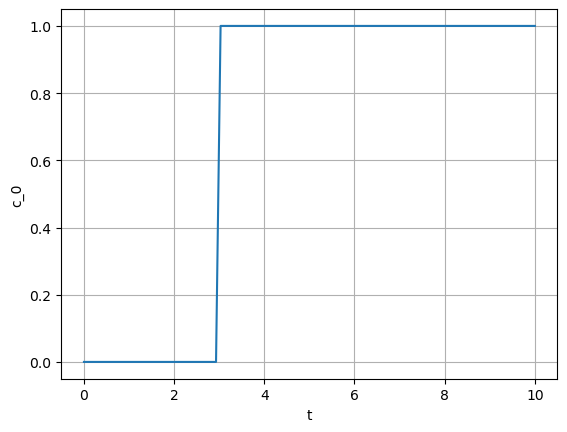

In [29]:
plt.plot(t, c_0, label="c_0")
plt.xlabel("t")
plt.ylabel("c_0")
plt.grid()
plt.show()

Now we need the convolution. 
The RTD to be folded with the input signal is commonly called the kernel or filter.


We use a kernel of length 100 spanning 10 seconds as well.


We start simple by just performing a convolution with a random kernel:

In [30]:
n_kernel = 100
t_kernel = torch.linspace(0, 10, n_kernel)

conv = torch.nn.Conv1d(
    in_channels=1,
    out_channels=1,
    kernel_size=n_kernel,
    bias=False,
    padding=n_kernel - 1,
    padding_mode="replicate",
)

E_guess = conv.get_parameter("weight")

and plot the kernel

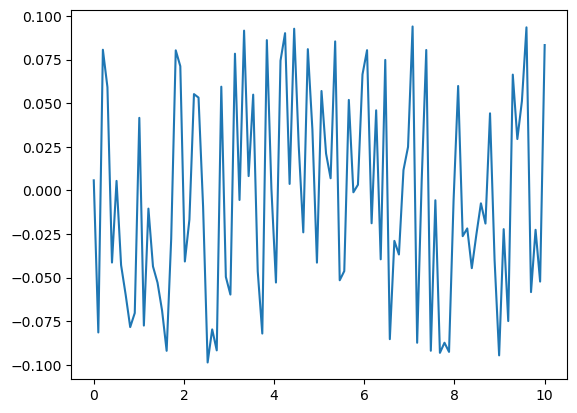

In [31]:
plt.plot(t_kernel, E_guess[0, 0, :].detach().numpy(), label="E_guess")

Now we can do the convolution.

We have to insert a second dimension to cast the shape of the concentration from `(100,)` to `(1,100)`. This is necessary because the convolution operator expects a tensor of shape `(in_chanels, n_input)` and outputs a tensor of shape `(out_chanels, n_output)`. What exactly these shapes are will be explained later.

In [32]:
print(c_0.shape)
print(c_0[None, :].shape)

torch.Size([100])
torch.Size([1, 100])


In [33]:
c = conv(c_0[None, :])

`c` is now our convoluted output (the prediction of the output signal).

To plot it we need to calculate a new time scale because the convolution messes with the tensor lengths. Important is the following:

$t_{0, \mathrm{c}}=t_{0, \mathrm{input}} + t_{0, \mathrm{kernel}}$

$t_{\mathrm{end}, \mathrm{c}}=t_{\mathrm{end}, \mathrm{input}} + t_{\mathrm{end}, \mathrm{kernel}}$

The spacing also changes. Therefore we need to dive into how convolution actually works.

Main takeaway: **For a *full* convolution the resulting output shape is**

$n_\mathrm{c} = n_\mathrm{input} + n_\mathrm{kernel} - 1$

In [34]:
c.shape

torch.Size([1, 199])

In [35]:
t_c = torch.linspace(t[0] + t_kernel[0], t[-1] + t_kernel[-1], n_disc + n_kernel - 1)
print(t_c.shape)

torch.Size([199])


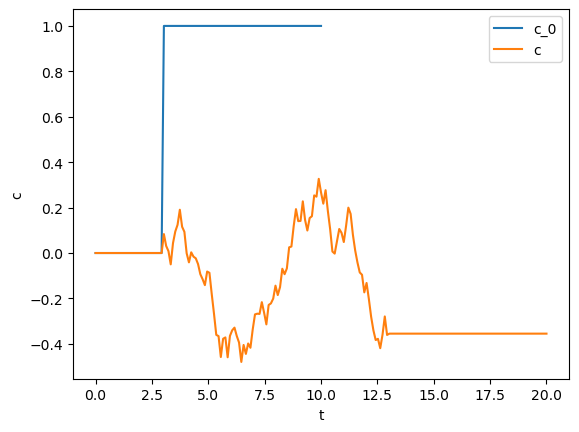

In [36]:
plt.plot(t, c_0, label="c_0")
plt.plot(t_c, c[0, :].detach().numpy(), label="c")
plt.legend()
plt.xlabel("t")
plt.ylabel("c")
plt.show()

Okay, not bad, it has done something.

However, the concentration got negative and the course is noinsense, but remember that our kernel is purely random. What can be seen though is that nothing happens to the output as long as nothing has happened to the input. Then it changes and after the kernel time it stays constant.

We can even look at the numbers in the kernel:

In [37]:
list(conv.parameters())

[Parameter containing:
 tensor([[[ 0.0058, -0.0815,  0.0806,  0.0592, -0.0414,  0.0054, -0.0429,
           -0.0598, -0.0784, -0.0703,  0.0416, -0.0775, -0.0105, -0.0436,
           -0.0529, -0.0690, -0.0920, -0.0277,  0.0803,  0.0712, -0.0408,
           -0.0167,  0.0552,  0.0532, -0.0092, -0.0987, -0.0797, -0.0917,
            0.0595, -0.0496, -0.0597,  0.0784, -0.0055,  0.0916,  0.0082,
            0.0549, -0.0464, -0.0821,  0.0862,  0.0010, -0.0528,  0.0744,
            0.0901,  0.0037,  0.0927,  0.0256, -0.0241,  0.0810,  0.0350,
           -0.0414,  0.0570,  0.0211,  0.0069,  0.0854, -0.0515, -0.0463,
            0.0519, -0.0011,  0.0032,  0.0665,  0.0804, -0.0189,  0.0459,
           -0.0395,  0.0748, -0.0853, -0.0289, -0.0368,  0.0117,  0.0249,
            0.0940, -0.0874,  0.0057,  0.0805, -0.0920, -0.0057, -0.0932,
           -0.0874, -0.0926, -0.0056,  0.0599, -0.0263, -0.0218, -0.0446,
           -0.0254, -0.0074, -0.0190,  0.0442, -0.0399, -0.0946, -0.0222,
           -0.0

This is the kernel. Let's build our own kernel by getting the data inside the NNs convolutions parameter and changing it to our liking:

In [38]:
E_guess.data = torch.zeros_like(E_guess.data)
E_guess.data[0, 0, t_kernel > 2] = 0.1
E_guess.data[0, 0, t_kernel > 4] = 0

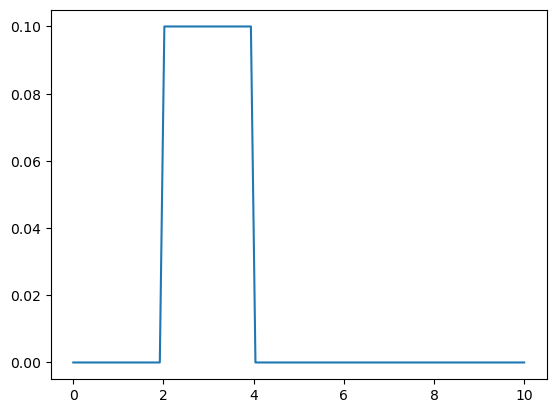

In [39]:
plt.plot(t_kernel, E_guess[0, 0, :].detach().numpy(), label="E_guess")

In [40]:
c = conv(c_0[None, :])

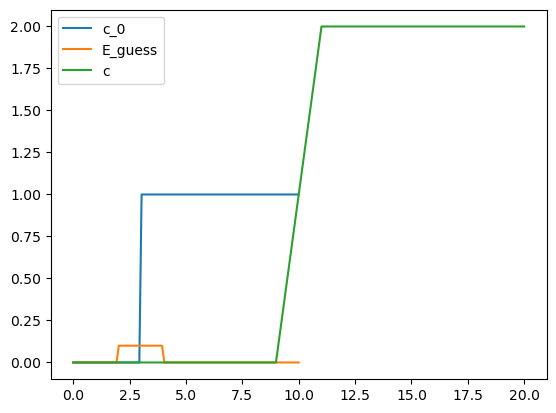

In [41]:
plt.plot(t, c_0, label="c_0")
plt.plot(t_kernel, E_guess[0, 0, :].detach().numpy(), label="E_guess")
plt.plot(t_c, c[0, :].detach().numpy(), label="c")
plt.legend()
plt.show()

Unfortunately this is wrong. Can you explain why?
Look at the time the output signal changes? Can it happen at that time?

In [46]:
E_guess.data = E_guess.data.flip(2)

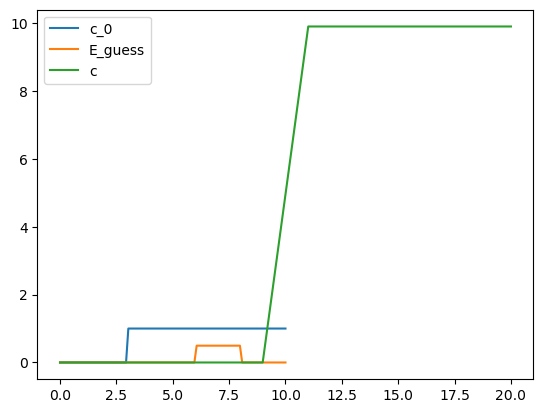

In [47]:
c = conv(c_0[None, :])
plt.plot(t, c_0, label="c_0")
plt.plot(t_kernel, E_guess[0, 0, :].flip(0).detach().numpy(), label="E_guess")
plt.plot(t_c, c[0, :].detach().numpy(), label="c")
plt.legend()
plt.show()

warmer, but still not right, can you explain why?

In [44]:
print(E_int := torch.trapz(E_guess[0, 0, :], dx=t_kernel[1] - t_kernel[0]))

E_guess.data = E_guess.data / E_int

tensor(0.2020, grad_fn=<MulBackward1>)


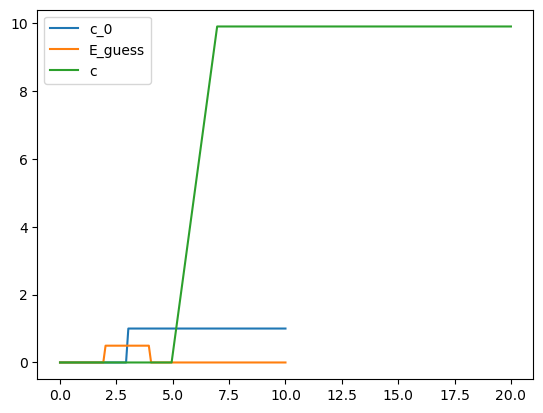

In [45]:
c = conv(c_0[None, :])
plt.plot(t, c_0, label="c_0")
plt.plot(t_kernel, E_guess[0, 0, :].flip(0).detach().numpy(), label="E_guess")
plt.plot(t_c, c[0, :].detach().numpy(), label="c")
plt.legend()
plt.show()

Now it's right!